<a href="https://colab.research.google.com/github/tanishataranoon/MY_ML_project/blob/main/Toxic_Text_Classification_Comparison_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud transformers torch --quiet

In [2]:
import pandas as pd
import tensorflow as tf
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 5)

In [4]:
from wordcloud import WordCloud
from nltk.corpus import stopwords

In [5]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [6]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [7]:
import string
nltk.download('omw-1.4')

sns.set_theme(style='whitegrid')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [8]:
import re
from collections import Counter

# Load dataset
from https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge?library=datasets


In [9]:
from datasets import load_dataset

df = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/68.8M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

test_labels.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]

In [10]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 306328
    })
})

In [11]:
train_df = df['train'].to_pandas()
test_df = df['test'].to_pandas()

Train data size and trained data

In [12]:
print(train_df.shape)
print(train_df.head())

(159571, 8)
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  


In [13]:
print('Columns: ', train_df.columns.tolist())

Columns:  ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [14]:
print('\nData Types: \n', train_df.dtypes)


Data Types: 
 id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object


In [15]:
print('\nMissing values:\n', train_df.isnull().sum())


Missing values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Test data size and test data

In [16]:
print(test_df.shape)
print(test_df.head())

(306328, 8)
                 id                                       comment_text  toxic  \
0  00001cee341fdb12  Yo bitch Ja Rule is more succesful then you'll...    NaN   
1  0000247867823ef7  == From RfC == \n\n The title is fine as it is...    NaN   
2  00013b17ad220c46  " \n\n == Sources == \n\n * Zawe Ashton on Lap...    NaN   
3  00017563c3f7919a  :If you have a look back at the source, the in...    NaN   
4  00017695ad8997eb          I don't anonymously edit articles at all.    NaN   

   severe_toxic  obscene  threat  insult  identity_hate  
0           NaN      NaN     NaN     NaN            NaN  
1           NaN      NaN     NaN     NaN            NaN  
2           NaN      NaN     NaN     NaN            NaN  
3           NaN      NaN     NaN     NaN            NaN  
4           NaN      NaN     NaN     NaN            NaN  


**Binary 'any_toxic' column **




In [17]:
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train_df['any_toxic'] = train_df[label_cols].max(axis=1)


print(f'Total comments    : {len(train_df):,}')
print(f'Toxic comments    : {train_df["any_toxic"].sum():,} ({train_df["any_toxic"].mean()*100:.1f}%)')
print(f'Non-toxic comments: {(train_df["any_toxic"]==0).sum():,} ({(train_df["any_toxic"]==0).mean()*100:.1f}%)')

Total comments    : 159,571
Toxic comments    : 16,225 (10.2%)
Non-toxic comments: 143,346 (89.8%)


In [18]:
# print(f'Total comments : {len(df):,}')
# print(f'Total toxic comments : {len(train_df[train_df.any_toxic == 1]):,}')
# print(f'Total non-toxic comments : {len(train_df[train_df.any_toxic == 0]):,}')

# Exploratory Data Analysis (EDA)

In [19]:
label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


Bar Chart of Number of Comments per Toxicity Label \
A pie chart for non-toxic vs toxic

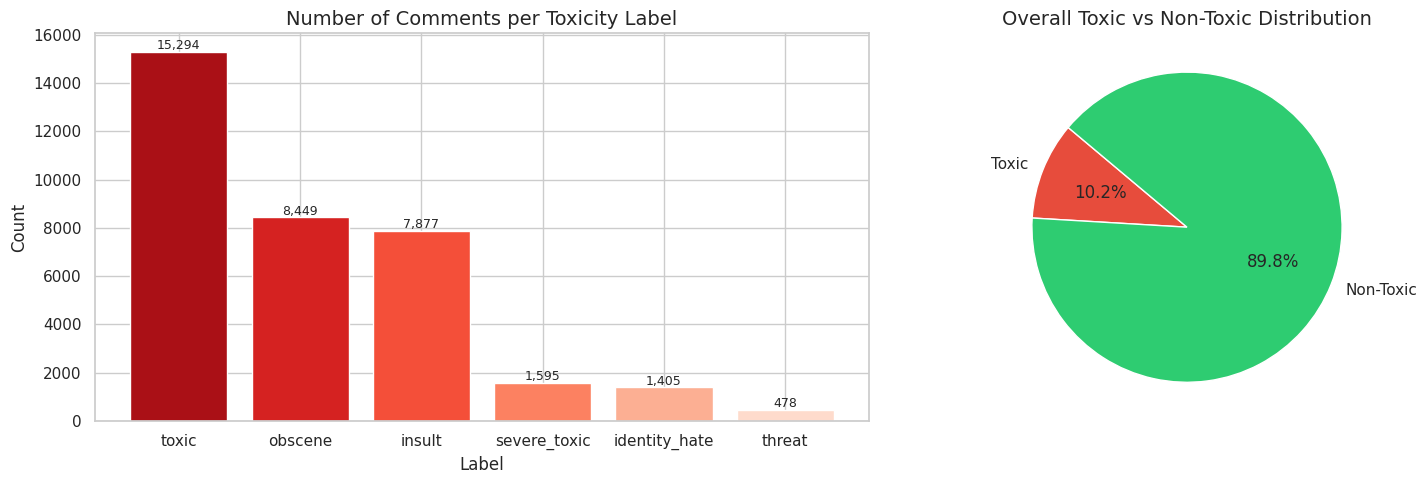

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette('Reds_r', len(label_cols)))
axes[0].set_title('Number of Comments per Toxicity Label', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    [train_df['any_toxic'].sum(), (train_df['any_toxic']==0).sum()],
    labels=['Toxic', 'Non-Toxic'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=140
)
axes[1].set_title('Overall Toxic vs Non-Toxic Distribution', fontsize=14)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



In [21]:
co_matrix = train_df[label_cols].T.dot(train_df[label_cols])
co_matrix

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405


Multi-label Co-occurrence Heatmap a comment can belong to multiple categories at the same time

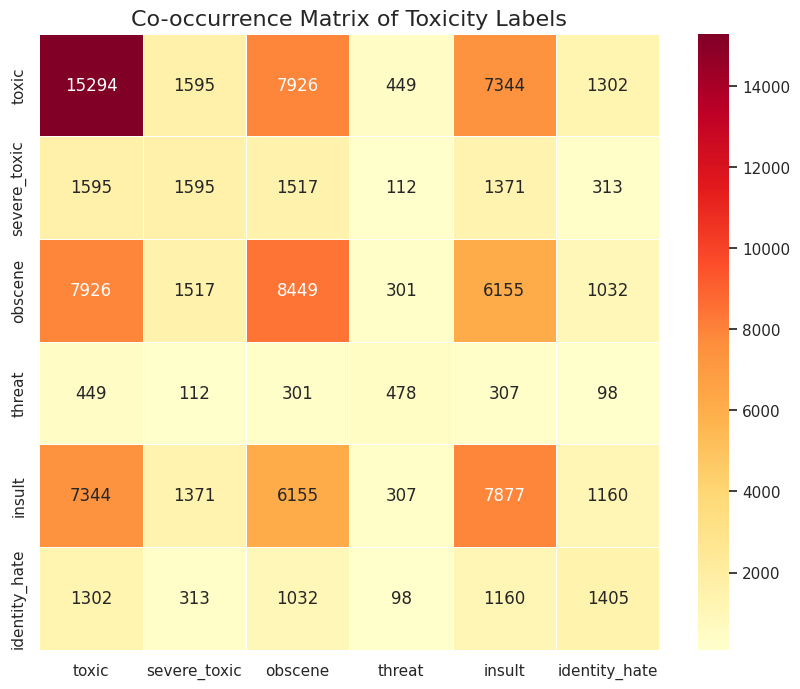

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix of Toxicity Labels', fontsize=16)
plt.savefig('co_occurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Word Cloud

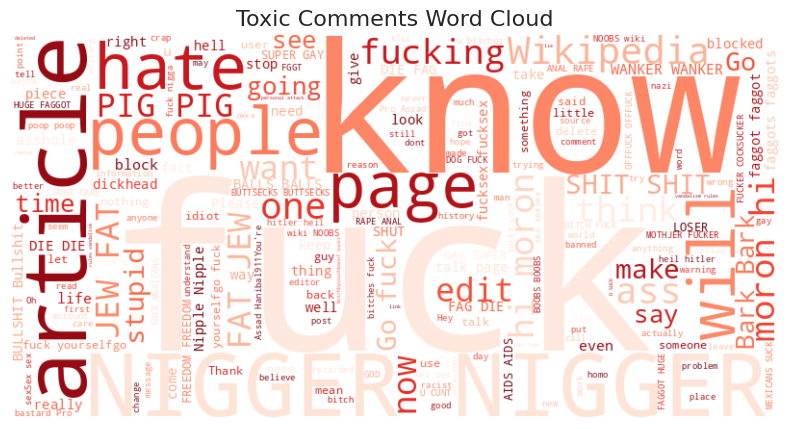

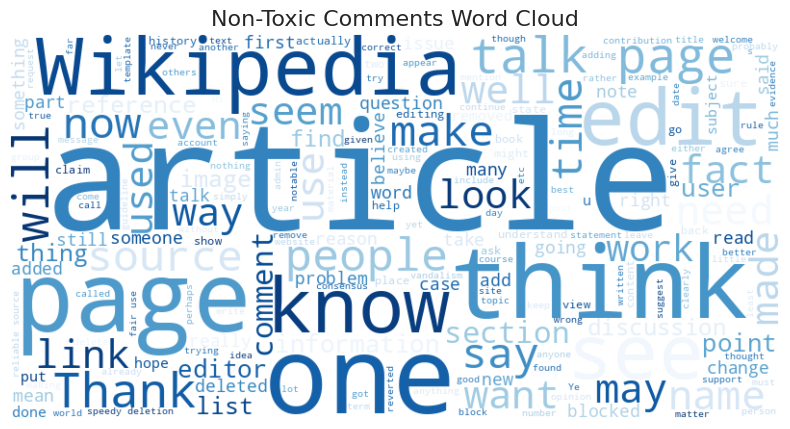

In [23]:
def generate_wordcloud(text_data, title, colormap='Reds'):
  text=' '.join(text_data)
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=colormap,
      max_words=200,
    ).generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(title, fontsize=16)
  plt.axis('off')
  plt.show()

generate_wordcloud(train_df[train_df['any_toxic'] == 1]['comment_text'], 'Toxic Comments Word Cloud','Reds')
generate_wordcloud(train_df[train_df['any_toxic'] == 0]['comment_text'], 'Non-Toxic Comments Word Cloud', 'Blues')

Most frequent words and phrases in toxic comments.
*   Unigrams → single words
*   Bigrams → two-word combinations

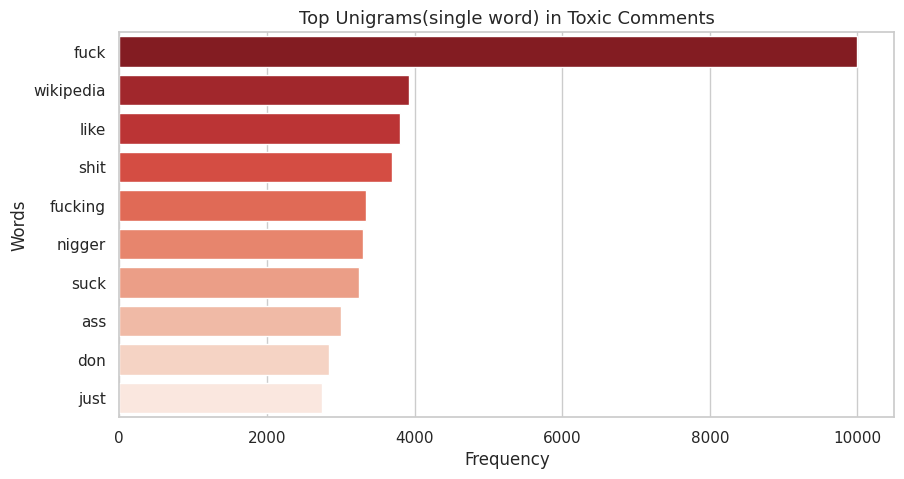

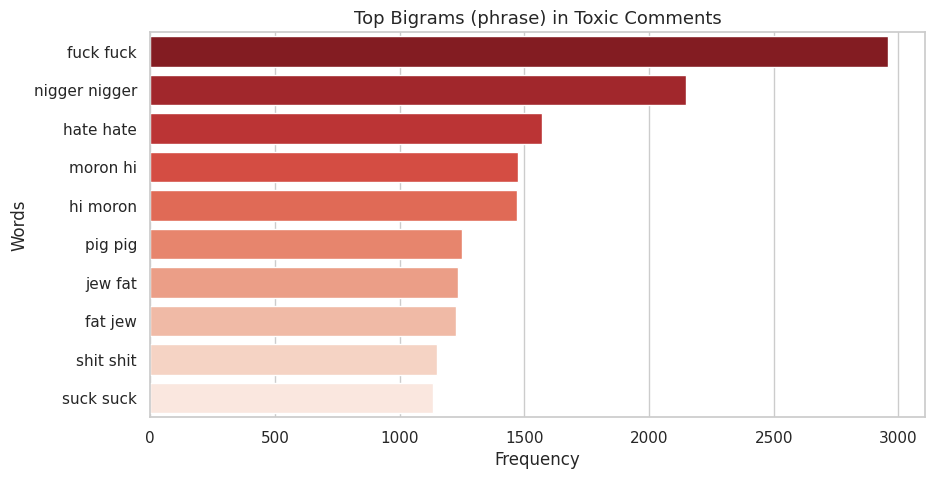

In [24]:
from numpy import vecdot
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngrams (corpus, title, ngram_range=(1,1), top_n=10):
  vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=1000).fit(corpus)
  bag_of_words = vec.transform(corpus)
  sum_words = bag_of_words.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

  top_n_ngrams = words_freq[:top_n]
  words = [word for word, freq in top_n_ngrams]
  freq = [freq for word, freq in top_n_ngrams]

  plt.figure(figsize=(10, 5))
  sns.barplot(
    x=list(freq),
    y=list(words),
    hue=list(words),
    palette='Reds_r',
    legend=False
  )
  plt.title(title, fontsize=13)
  plt.xlabel('Frequency', fontsize=12)
  plt.ylabel('Words', fontsize=12)
  plt.show()

toxic_comments = train_df[train_df['any_toxic'] == 1]['comment_text'].dropna()

get_top_ngrams(toxic_comments, 'Top Unigrams(single word) in Toxic Comments', ngram_range=(1,1), top_n=10)
get_top_ngrams(toxic_comments, 'Top Bigrams (phrase) in Toxic Comments', ngram_range=(2,2), top_n=10)

# PreProcessing

**Raw data from the trained dataset before any
pre processing **

In [25]:
train_df[['comment_text', "toxic"]].sample(6)

,comment_text,toxic
59186,Are you saying that one person is the entire c...,0
88038,I'll givi it a try. Actually planned on doing ...,0
149143,Toyota have withdrawn the car. Dead issue.,0
63749,"""\nI love """"Oh, my"""" ... did you know I taught...",0
88196,OMG....are you slow man??? I AM NOT MAKING PER...,1
61331,"Nope, that's a POV comment. 'Satirically' sugg...",0


**Basic Preprocessing**



1.   Lower case




In [26]:
def to_lower(text):
    return text.lower()


2.   URL remove



In [27]:
def remove_urls(text):
    import re
    return re.sub(r"http\S+|www\S+", "", text)


3. Mentions remove



In [28]:
def remove_mentions(text):
    import re
    return re.sub(r"@\w+", "", text)



4. Remove Punctuation



In [29]:
def remove_punctuation(text):
    import re
    return re.sub(r"[^a-zA-Z\s]", "", text)


5. Remove extra space




In [30]:
def remove_extra_spaces(text):
    import re
    return re.sub(r"\s+", " ", text).strip()

<!-- 6. Stopword removed -->

In [31]:
# def stopword_removal(text):
#     stopwords = {"the", "is", "a", "an"}
#     return " ".join([w for w in text.split() if w not in stopwords])

**Advance Preprocessing**

In [32]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 18.7 MB/s eta 0:00:00


1. Emoji to text

In [33]:
import emoji

def emoji_to_text(text):
  return emoji.demojize(text, delimiters=(" ", " "))

 2. Convert to full forms



In [34]:
# def expand_contractions(text):
#   contractions = {
#     "ain't": "is not",
#     "aren't": "are not",
#     "can't": "cannot",
#     "can't've": "cannot have",
#     "'cause": "because",
#     "don't": "do not",
#     "you're": "you are",
#     "it's": "it is",
#     "i'm": "i am",
#     "won't": "will not"
#   }
#   for k,v in contractions.items():
#       text = text.replace(k,v)
#       return text



In [35]:
def expand_contractions(text):
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "don't": "do not",
        "you're": "you are",
        "it's": "it is",
        "i'm": "i am",
        "won't": "will not"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    return text

3. Normalize repetitions\
stuuuuupid → stupid

In [36]:
def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

4. Bad Word Normalization\
b!tch = bitch

In [37]:
def normalize_obscene(text):
    text = text.replace("b!tch", "bitch")
    text = text.replace("f*ck", "fuck")
    text = text.replace("a$$", "ass")
    return text

5. Tokenization

In [38]:
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer

In [39]:
# sample_text = train_df['comment_text'].iloc[0]

# clean_text = advanced_preprocess(sample_text)
# tokens = word_tokenize(clean_text)
def tokenize_text(text):
    return word_tokenize(text)

In [40]:
# print("Original text:", sample_text)
# print("Clean text:", clean_text)
# print("Tokens:", tokens)

Stopwords

In [41]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# stop_words = set(stopwords.words('english'))
# stopwords=True
# if stopwords:
#         tokens = [t for t in tokens if t not in stop_words]
#         print("Tokens after removing stop words:", tokens)

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]


Lemmatize

In [42]:
# lemmatizer = WordNetLemmatizer()
# lemmatize=True
# if lemmatize:
#         tokens = [lemmatizer.lemmatize(t) for t in tokens]
#         print('tokens after Lammatization: ', tokens)

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

PreProcess function

In [43]:
def basic_preprocess(text):
    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)
    return text

In [44]:
# def advanced_preprocess(text,remove_sw=True,lemmatize=True):
#     text = emoji_to_text(text)
#     text = expand_contractions(text)
#     text = normalize_obscene(text)
#     text = normalize_repeated_chars(text)
#     text = to_lower(text)
#     text = remove_urls(text)
#     text = remove_mentions(text)
#     text = remove_punctuation(text)
#     text = remove_extra_spaces(text)
#     tokens = tokenize_text(text)
#     if lemmatize:
#         tokens = lemmatize_tokens(tokens)
#     return text

In [45]:
def advanced_preprocess(text, remove_sw=True, lemmatize=True):
    text = emoji_to_text(text)
    text = expand_contractions(text)
    text = normalize_obscene(text)
    text = normalize_repeated_chars(text)

    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    tokens = tokenize_text(text)

    if remove_sw:
        tokens = remove_stopwords(tokens)

    if lemmatize:
        tokens = lemmatize_tokens(tokens)

    return " ".join(tokens)

# Apply the preprocessing

Before Applying

In [46]:
pd.set_option('display.max_colwidth', None)
train_df["raw"] = train_df["comment_text"]
train_df[["raw"]].sample(5)


,raw
85429,"FACT - Roy Webber was born in 1914.\nFACT - Harry Altham published the first edition of his history in 1926.\nFACT - I passed my GCE history and went on to get an MSc.\nQUESTION - If your college deprecates WP, what are you doing on here?\nOPINION - It is probably because of incompetents like you that WP has a poor reputation in some quarters.\nOPINION - What a cretin. \nFINAL WORDS - Goodbye. Paul. 86.134.59.236"
96442,"Aspiring to become an admin?\n\nWhy is that important to you (Noticed it on your userpage) Is that why you cozy up to Schumin and others here, because you are trying to become an Admin? Where is your pride man. 86.40.200.196 \n\nPerhaps you should actually edit articles before looking for adminship. Adminship (Going by the crop of people who do it here) seems to attract fat lardo's who never got dates trying to release some sexual frustration. They probably ran out of porn. Anyway, good luck, but maybe you'd be better getting a life, a girlfriend and a hobby? Wasting your life away using the likes of Schumin as a role model won't get you very far. 86.40.200.196"
56374,"Please stop. If you continue to vandalize pages by deliberately introducing incorrect information, you will be blocked from editing Wikipedia. \nIf this is a shared IP address, and you didn't make any unconstructive edits, consider creating an account for yourself so you can avoid further irrelevant warnings."
140792,"Also, the level of detail included is probably inappropriate for the introductory paragraph."
19661,"""\n\nRandyKitty, none of these """"collaborators"""" did anything. I welcome their collaboration! Let them add a single line, or even delete a line that they think is unimportant! Mass deleting is not a """"collaboration"""" and you are abusing language to make your point. I am the only one who collaborated on here. Take a look at the record, and you shall see I collaborated with at least 4 other editors before 2 """"collaborators"""" (who are collaborators in the sense that the French were collaborators with Hitler) simply mass deleted contributions, rather than selectively keeping what they liked or approved of. Please stop abusing language. """


Applying Basic Preprocessing

In [47]:

train_df["basic_clean"] = train_df["raw"].apply(basic_preprocess)
train_df[["basic_clean"]].sample(5)

,basic_clean
8933,some ratings from the vchip the power tvpgl hell shit pissed just set up the chairs tvpgv the destroyer of world murders caffeinated concert tickets tvpgd lady pecs boobs real reason people go to concerts is too see hot girls death punchies tvpgv death kwon do rigbys bare ass free cake tvpgl pissed meat your maker tvpglv pissed cannibalistic hot dogs grilled cheese deluxe tvpg purple nurple suggestive touching the unicorns got to go tvpgdv lady flashbacks risque goth lady eating crotch balls attack of the unicorns prank callers tvpg brain tumor don tvpgd don reveals all the characters are naked sugar seems gay rigbys body tvpgl sucks turds mordecai and the rigbys tvpg crotch humps ello govnor tvpgv evil taxi its time tvpgd rigby tonguekissing margaret discussing how good movies have sex appreciation day tvpg nothing wrong peeps tvpg implied naked pops dizzy tvpg implied naked pops my mom tvpgd my mom jokes imply sex high score tvpg gbf kicked in the crotch rage against the tv tvpgv kick him in the junk hammers killings party pete tvd guests with breasts line breast zoomins sexual dancing with pops petes groin lump shown brain eraser tv naked pops seen throughout whole episode implied long penis scene junk benson be gone tvpg nothing wrong but i have a receipt tvpgv the stabbing this is my jam tvpg gutters crotch humps muscle woman tvds junk tonguekiss big breasted starla temp check tvpg nothing wrong jinx tvpgv jinx monsters attack nsfw remark on dirty raccoon naked people see you there tvpg nothing wrong do me a solid tvpg shake weight grave sights tvpgv zombies really real wrestling tvpgv wrestlers over the top tvpgv rigbys death the night owl tvpgd second base a bunch of baby ducks tvpg more smarter tvpg first day tvpg go viral tvpg panties skunked tvpg karaoke show tvpg stick hockey tvpg chinese man named chong like ching chong bet to be blonde tvpg blonde stereotypes
66943,why are you hell bent in highlighting the muhajir background of imran farooq whats up with that
38398,i think you should unblock me because i was only pointing out that the pashtun people were a bunch of aidz infected niggers why do you have them as a featured article fucking monkeys
20363,also onc again its not my qualms i was citing only other people
149388,solomon has added some more fuel to the fire and good for him great article on april th about some more of the shenanigans going on on this topic link is here


Comparison Of Raw and Basic Clean by Basic Preprocessing

In [48]:
pd.set_option('display.max_colwidth', None)
train_df[["raw", "basic_clean"]].sample(5)

,raw,basic_clean
17380,"""\n\n Rafael Nadal \n\nThe division of articles is not a content fork; it's a means to reduce the sizes of the articles without having the delete a ton of information from Wikipedia. How is that contrary to the guidelines? See: Article spinouts – """"Summary style"""" articles. on(t) """,rafael nadal the division of articles is not a content fork its a means to reduce the sizes of the articles without having the delete a ton of information from wikipedia how is that contrary to the guidelines see article spinouts summary style articles ont
71163,"Christianity is only mentioned three times in the article so the entire article can't have an anti-christian tone. Two out of three times, the mention of Christianity is in reference to Christians and conservatives blaming popular culture for the massacre, which actually did occur (so it deserves mention). The only bias I do notice is the mention of using Cassie Bernall to boast popularity for their faith despite the truth of the matter, but this can be easily changed to an NPOV without deleting the fact.",christianity is only mentioned three times in the article so the entire article cant have an antichristian tone two out of three times the mention of christianity is in reference to christians and conservatives blaming popular culture for the massacre which actually did occur so it deserves mention the only bias i do notice is the mention of using cassie bernall to boast popularity for their faith despite the truth of the matter but this can be easily changed to an npov without deleting the fact
55386,"did a revert on annual-reviews inc, added link on its standards-of-operation page. Non-profit means bound to economic restrictions at 94% costs and 80% tax, not expressing pure altruism... not serving the demands of the public... Its just something among the spectrum of E.K., AG, KG, GmbH, gGmbH, e.V., Individual in german terminology, indeed nothing worth-mention at all... Less tax, less management freedom. One should say, the category is intrinsically misleading, and I fell into the trap.",did a revert on annualreviews inc added link on its standardsofoperation page nonprofit means bound to economic restrictions at costs and tax not expressing pure altruism not serving the demands of the public its just something among the spectrum of ek ag kg gmbh ggmbh ev individual in german terminology indeed nothing worthmention at all less tax less management freedom one should say the category is intrinsically misleading and i fell into the trap
132306,REDIRECT Talk:List of thread standards,redirect talklist of thread standards
22197,"""\n\n personal union \n\nI just wandered by and stumbled over the disputed-accuracy template in the given article. If this dispute has been resolved, may I suggest you remove same? (Actually, I'll do so as that was three+ months ago). From the article history it looks to be pretty stable, so this kind of untidyness is unwelcome in a matured article. OTOH, an update of the current dispute state would be in order as would a new line in the article history saying that you reasserted the template 'because... [New Section Name] is disputed'. Thanks, A text search for dispute in the history going back 120 changes or so didn't find it! Time consuming, apparently for nothing much. \nBest regards, nkB """,personal union i just wandered by and stumbled over the disputedaccuracy template in the given article if this dispute has been resolved may i suggest you remove same actually ill do so as that was three months ago from the article history it looks to be pretty stable so this kind of untidyness is unwelcome in a matured article otoh an update of the current dispute state would be in order as would a new line in the article history saying that you reasserted the template because new section name is disputed thanks a text search for dispute in the history going back changes or so didnt find it time consuming apparently for nothing much best regar

Applying Advanced Preprocessing

In [49]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [50]:
train_df["advanced_clean"] = train_df["raw"].apply(advanced_preprocess)
train_df[["advanced_clean"]].sample(5)

,advanced_clean
37631,electriccatfish user francisrowe dispute yesterday article wrote nobody favour anyone else behaviour exactly ideal tone since come realize error way short sincerest apology order
22883,microsoft confirmed upper hardware limit xp set follows main storage max builtin flash drive gb andor hard drive gb graphic greater directx capability main memory greater gb cpu singlecore ghz unless one following intel atom n n z z z z z intel celeron amd geode lx athlon e sempron u via cm ulv neon u u u cpu screen size netbook inch large screen netbook inch nettop limit given itexaminer may
34620,game coming gamestop absolute proof let put stuff back noone gay
155497,article seems assume reader already knowledge article impart
145179,wish well hi rick hope youll reconsider quitting wikipedia btw great likeness


Comparison of Raw and Advanced Clean by Advanced Preprocessing


In [51]:
pd.set_option('display.max_colwidth', None)
train_df[["raw","advanced_clean"]].sample(5)

,raw,advanced_clean
133777,Happy Editing! J Klein my talk my contributions,happy editing j klein talk contribution
76402,"Your new version is indeed better, and in my opinion it is largely fine (I only made a minor addition, that the Confession also states that the manner of change cannot be explained, since this was underlined in some of the sources shown earlier).",new version indeed better opinion largely fine made minor addition confession also state manner change explained since underlined source shown earlier
19034,REDIRECT Talk:Criticism of Dish Network,redirect talkcriticism dish network
72094,"""\n\nThanks for participating in Women in architecture\nThank you for your participation in the Women in Architecture Virtual Edit-a-thon, 15–25 October 2015, sponsored by the Guggenheim Museum, and hosted by Women in Red. In addition to upgrades, we created about 170 new articles. Your contributions are appreciated! \n""",thanks participating woman architecture thank participation woman architecture virtual editathon october sponsored guggenheim museum hosted woman red addition upgrade created new article contribution appreciated
72090,"""\nWell, in my view, the language I was using to challenge my worthy opponent——was utterly absurd, which meant it never even crossed my mind that someone could take Wikicaffeine as a """"last meal"""" to be a threat of any kind, let alone physical violence. For your information, I purchased my """"simple sword of truth"""" from one of our ridiculous politicians of yesteryear:\nIf it falls to me to start a fight to cut out the cancer of bent and twisted journalism in our country with the simple sword of truth and the trusty shield of British fair play, so be it. I am ready for the fight. The fight against falsehood and those who peddle it.\nI will definitely also equip myself with the """"trusty shield of British fair play"""" the next time I have cause to unsheathe the """"simple sword of truth"""".Let us all put this unfortunate and silly episode behind us. Let us venture forth and create featured articles out of stubs, make unfailing use of inline citations and RS, and so on. Best wishes! """,well view language using challenge worthy opponentwas utterly absurd meant never even crossed mind someone could take wikicaffeine last meal threat kind let alone physical violence information purchased simple sword truth one ridiculous politician yesteryear fall start fight cut cancer bent twisted journalism country simple sword truth trusty shield british fair play ready fight fight falsehood peddle definitely also equip trusty shield british fair play next time cause unsheathe simple sword truthlet u put unfortunate silly episode behind u let u venture forth create featured article stub make unfailing use inline citation r best wish


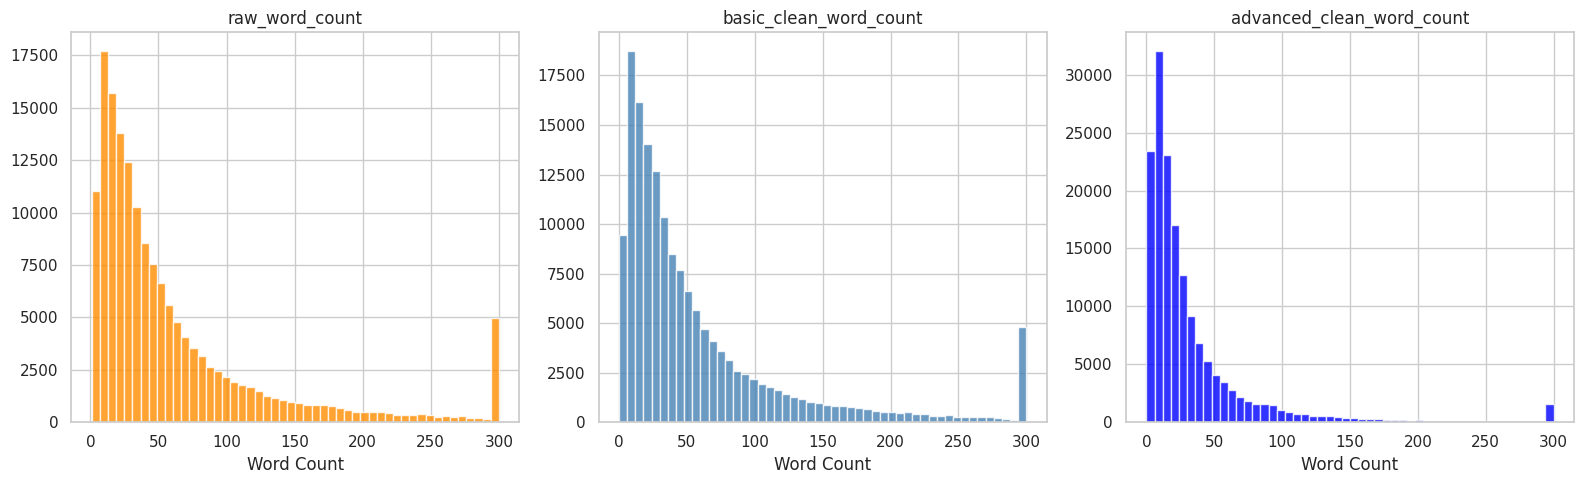

In [52]:
train_df['raw_word_count'] =train_df['comment_text'].str.split().str.len()
train_df['basic_clean_word_count'] =train_df['basic_clean'].str.split().str.len()
train_df['advanced_clean_word_count'] =train_df['advanced_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
axes[0].hist(train_df['raw_word_count'].clip(upper=300),bins=50,color="darkorange", edgecolor='white',alpha=0.8)
axes[0].set_title('raw_word_count' , fontsize=12)
axes[0].set_xlabel('Word Count')


axes[1].hist(train_df['basic_clean_word_count'].clip(upper=300),bins=50,color="steelblue", edgecolor='white',alpha=0.8)
axes[1].set_title('basic_clean_word_count' , fontsize=12)
axes[1].set_xlabel('Word Count')


axes[2].hist(train_df['advanced_clean_word_count'].clip(upper=300),bins=50,color="blue", edgecolor='white',alpha=0.8)
axes[2].set_title('advanced_clean_word_count' , fontsize=12)
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [53]:
print('Raw text stats:')    ; print(train_df['raw_word_count'].describe().round(1))
print('\n basic Cleaned text stats:'); print(train_df['basic_clean_word_count'].describe().round(1))
print('\n advance Cleaned text stats:'); print(train_df['advanced_clean_word_count'].describe().round(1))


Raw text stats:
count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: raw_word_count, dtype: float64

 basic Cleaned text stats:
count    159571.0
mean         65.4
std          97.3
min           0.0
25%          16.0
50%          35.0
75%          73.0
max        1403.0
Name: basic_clean_word_count, dtype: float64

 advance Cleaned text stats:
count    159571.0
mean         34.0
std          52.5
min           0.0
25%           8.0
50%          18.0
75%          37.0
max        1250.0
Name: advanced_clean_word_count, dtype: float64


In [54]:
(train_df['basic_clean'] == train_df['advanced_clean']).sum()

np.int64(3383)

In [55]:
for i in range(2):
    print("RAW:", train_df['comment_text'].iloc[i])
    print("BASIC:", train_df['basic_clean'].iloc[i])
    print("ADVANCED:", train_df['advanced_clean'].iloc[i])
    print("-"*50)

RAW: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
BASIC: explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now
ADVANCED: explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please remove template talk page since im retired
--------------------------------------------------
RAW: D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)
BASIC: daww he matches this background colour im seemingly stuck with thanks talk january utc
ADVANCED: daww match background colou

# Train  Validation  Test Split

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [57]:
x = train_df[['raw','basic_clean','advanced_clean']]
y = train_df[label_counts.index]

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df['any_toxic']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED,
    stratify=y_temp.max(axis=1)
)

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')

Train : 127,656  |  Val : 15,957  |  Test : 15,958


# Feature Extraction

1. TF_IDF (for LR and SVM) \
use advanced_clean

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [59]:
tfidf = TfidfVectorizer(
    max_features=50000 ,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df =3
)
X_train_tfidf = tfidf.fit_transform(X_train['advanced_clean'])
X_val_tfidf = tfidf.transform(X_val['advanced_clean'])
X_test_tfidf = tfidf.transform(X_test['advanced_clean'])


In [60]:
print('TD_IFD shape train', X_train_tfidf.shape)
print('TD_IFD shape val', X_val_tfidf.shape)
print('TD_IFD shape test', X_test_tfidf.shape)

TD_IFD shape train (127656, 50000)
TD_IFD shape val (15957, 50000)
TD_IFD shape test (15958, 50000)


2. Tokenization & Padding (for LSTM) \
basic_clean

In [61]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import pad_sequences



In [101]:
Vocab_size =10000
max_len= 100

lstm_tok = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok.fit_on_texts(X_train['basic_clean'])

def to_padded(texts):
  seqs = lstm_tok.texts_to_sequences(texts)
  return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
X_train_lstm = to_padded(X_train['basic_clean'])
X_val_lstm = to_padded(X_val['basic_clean'])
X_test_lstm = to_padded(X_test['basic_clean'])

In [100]:
train_df['comment_text'].apply(lambda x: len(str(x).split())).describe()

,comment_text
count,159571.000000
mean,67.273527
std,99.230702
min,1.000000
25%,17.000000
50%,36.000000
75%,75.000000
max,1411.000000


In [63]:
print('LSTM shape train', X_train_lstm.shape)
print('LSTM shape val', X_val_lstm.shape)
print('LSTM shape test', X_test_lstm.shape)

LSTM shape train (127656, 100)
LSTM shape val (15957, 100)
LSTM shape test (15958, 100)


3. BERT Tokenizer (for BERT) \
raw dataset

In [64]:
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)

In [65]:
Bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def bert_encode(texts, max_len=512):
   enc =bert_tokenizer(
       list(texts),
       max_length=max_len,
       truncation=True,
       padding = 'max_length',
       return_tensors='tf'
   )
   return enc['input_ids'], enc['attention_mask']

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Evaluation toolkit
for comparing easily

In [66]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)


In [67]:
results ={}
def evaluate(model_name,y_true,y_pred, elapsed_train=None,elapsed_infer=None ):
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='macro',zero_division=0)
  rec = recall_score(y_true, y_pred, average='macro',zero_division=0)
  f1 = f1_score(y_true, y_pred, average='macro',zero_division=0)

  results[model_name] = {
      'accuracy': round(acc,4),
      'precision': round(prec,4),
      'recall': round(rec,4),
      'f1 (macro)': round(f1,4),
      'train time (s)':round( elapsed_train,1) if elapsed_train else '-',
      'infer time (s)': round(elapsed_infer,1) if elapsed_infer else '-'
  }
  print(f'\n===== {model_name} =====')
  print(f'  accuracy : {acc:.4f}')
  print(f'  precision: {prec:.4f}')
  print(f'  recall   : {rec:.4f}')
  print(f'  f1 Macro : {f1:.4f}')
  if elapsed_train: print(f'  train time: {elapsed_train:.1f}s')
  return results[model_name]


In [68]:
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score
# )

# results = {}

# def evaluate(model_name, y_true, y_pred, y_prob=None,
#              elapsed_train=None, elapsed_infer=None):

#     acc = accuracy_score(y_true, y_pred)

#     prec = precision_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     rec = recall_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     macro_f1 = f1_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     weighted_f1 = f1_score(
#         y_true, y_pred,
#         average='weighted',
#         zero_division=0
#     )

#     # ROC-AUC
#     if y_prob is not None:
#         roc_auc = roc_auc_score(
#             y_true,
#             y_prob,
#             average='macro'
#         )
#     else:
#         roc_auc = None

#     results[model_name] = {
#         'accuracy': round(acc, 4),
#         'precision': round(prec, 4),
#         'recall': round(rec, 4),
#         'macro f1': round(macro_f1, 4),
#         'weighted f1': round(weighted_f1, 4),
#         'roc-auc': round(roc_auc, 4) if roc_auc else '-',
#         'train time (s)': round(elapsed_train, 1) if elapsed_train else '-',
#         'infer time (s)': round(elapsed_infer, 1) if elapsed_infer else '-'
#     }

#     print(f'\n===== {model_name} =====')
#     print(f'Accuracy     : {acc:.4f}')
#     print(f'Precision    : {prec:.4f}')
#     print(f'Recall       : {rec:.4f}')
#     print(f'Macro F1     : {macro_f1:.4f}')
#     print(f'Weighted F1  : {weighted_f1:.4f}')

#     if roc_auc is not None:
#         print(f'ROC-AUC      : {roc_auc:.4f}')

#     if elapsed_train:
#         print(f'Train time   : {elapsed_train:.1f}s')

#     return results[model_name]

In [69]:
def plot_confusion(model_name,y_true, y_pred, labels, lables=label_cols):
   fig, axes = plt.subplots( 2,3, figsize=(15,8))
   for ax, col in zip(axes.flatten(), labels):
       cm = confusion_matrix(y_true[:, labels.index(col)],
                              y_pred[:, labels.index(col)])
       sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    cmap='Blues', cbar=False)
       ax.set_title(col, fontsize=11)
       ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
   plt.suptitle(f'Confusion Matrices — {model_name}', fontsize=14)
   plt.tight_layout()
   plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
   plt.show()

print('Evaluation helpers ready.')

Evaluation helpers ready.


# Model 1 — TF-IDF + Logistic Regression



## 1. Raw text version



In [70]:
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Model
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

In [71]:
tfidf_raw = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_raw = tfidf_raw.fit_transform(X_train['raw'])
X_test_tfidf_raw = tfidf_raw.transform(X_test['raw'])

lr_raw = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_raw.fit(X_train_tfidf_raw, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_raw = lr_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0


Train time: 17.3s


In [72]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [basic_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_raw.transform(sample_clean)

probs = lr_raw.predict_proba(sample_tfidf)

threshold = 0.5

for text, prob in zip(sample_comments, probs):

    print("\nComment:", text)

    toxic_found = False

    for label, p in zip(label_cols, prob):

        if p > threshold:
            toxic_found = True
            print(f"{label}: {p:.2%}")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: 100.00%
severe_toxic: 96.38%
obscene: 99.99%

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: 99.84%
severe_toxic: 82.45%
obscene: 96.65%

Comment: Amazing work
Prediction: Non-toxic


Evaluate the model for raw data

In [73]:
evaluate('TF-IDF + LR (raw)', y_test.values, y_pred_raw, train_t, infer_t)


===== TF-IDF + LR (raw) =====
  accuracy : 0.9204
  precision: 0.8366
  recall   : 0.3936
  f1 Macro : 0.5099
  train time: 17.3s


{'accuracy': 0.9204,
 'precision': 0.8366,
 'recall': 0.3936,
 'f1 (macro)': 0.5099,
 'train time (s)': 17.3,
 'infer time (s)': 0.0}

In [74]:
# y_prob_raw = lr_raw.predict_proba(X_test_tfidf_raw)

# evaluate(
#     'TF-IDF + LR (raw)',
#     y_test.values,
#     y_pred_raw,
#     y_prob=y_prob_raw,
#     elapsed_train=train_t,
#     elapsed_infer=infer_t
# )

Confusion plot for the model for raw data

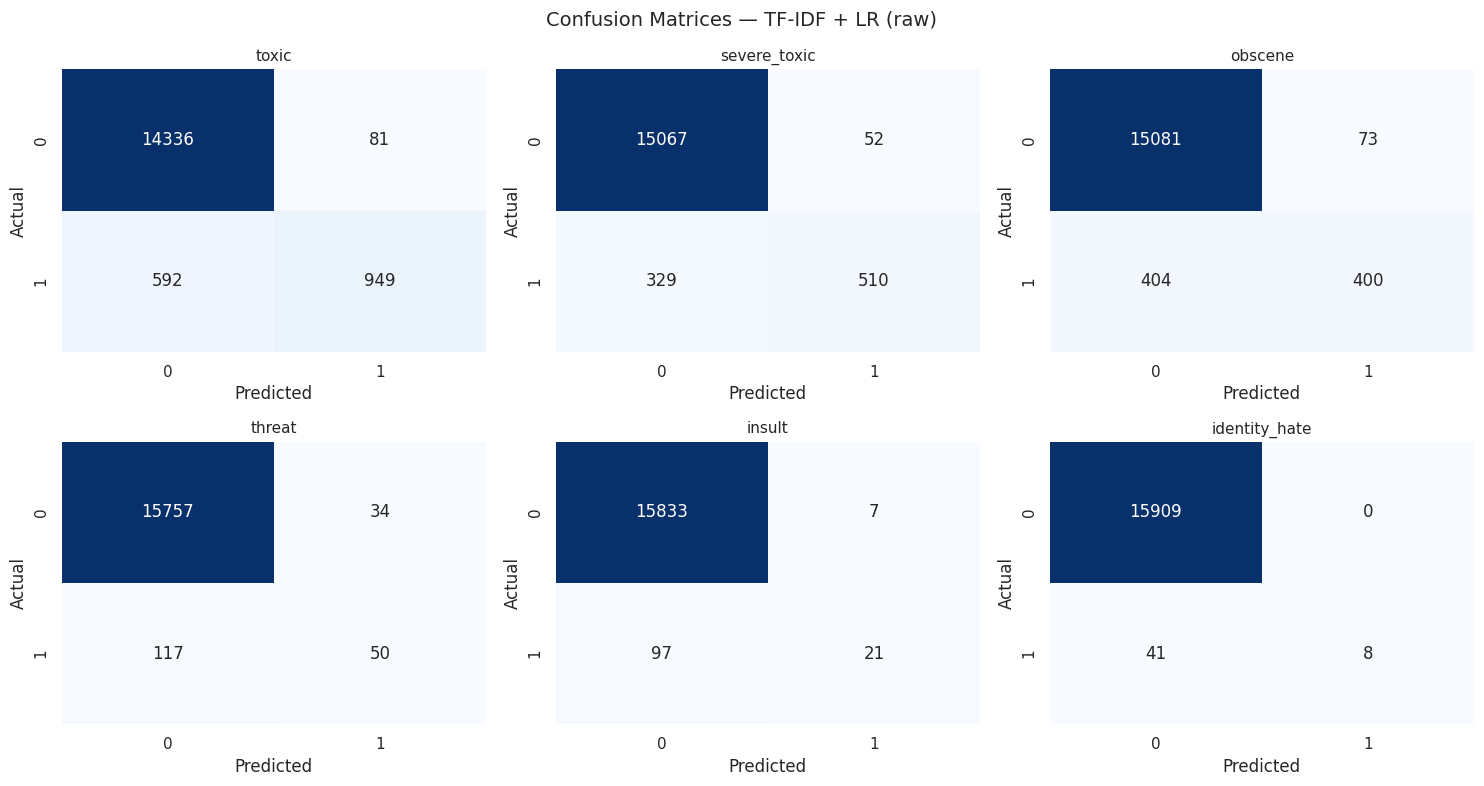

In [75]:
plot_confusion('TF-IDF + LR (raw)', y_test.values, y_pred_raw, label_cols)

## 2. Advanced clean version

In [76]:
tfidf_clean = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_clean = tfidf_clean.fit_transform(X_train['advanced_clean'])
X_test_tfidf_clean = tfidf_clean.transform(X_test['advanced_clean'])

lr_clean = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_clean.fit(X_train_tfidf_clean, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_clean = lr_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 11.4s


In [77]:
evaluate('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, train_t, infer_t)


===== TF-IDF + LR (advanced) =====
  accuracy : 0.9189
  precision: 0.7585
  recall   : 0.3845
  f1 Macro : 0.4852
  train time: 11.4s


{'accuracy': 0.9189,
 'precision': 0.7585,
 'recall': 0.3845,
 'f1 (macro)': 0.4852,
 'train time (s)': 11.4,
 'infer time (s)': 0.0}

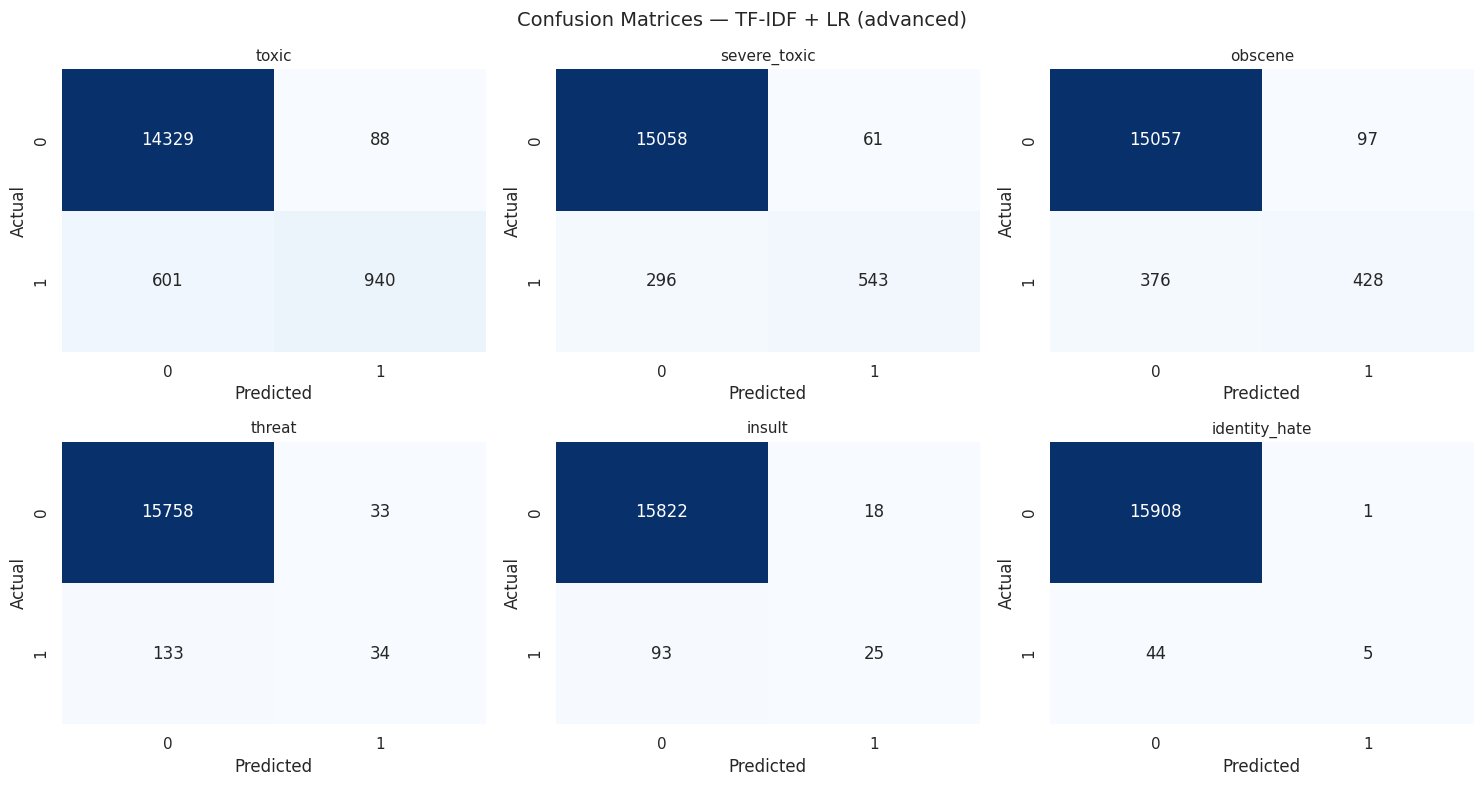

In [78]:
plot_confusion('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, label_cols)

The raw-text TF-IDF representation outperformed the advanced preprocessed version across all evaluation metrics. Excessive preprocessing may remove important contextual and emotional cues that contribute to toxicity identification.

In [79]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [advanced_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_clean.transform(sample_clean)

probs = lr_clean.predict_proba(sample_tfidf)

threshold = 0.5

for text, prob in zip(sample_comments, probs):

    print("\nComment:", text)

    toxic_found = False

    for label, p in zip(label_cols, prob):

        if p > threshold:
            toxic_found = True
            print(f"{label}: {p:.2%}")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: 100.00%
severe_toxic: 98.77%
obscene: 100.00%

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: 99.96%
severe_toxic: 89.89%
obscene: 98.20%

Comment: Amazing work
Prediction: Non-toxic


# **Model 2 — TF-IDF + SVM (LinearSVC)**

**Raw version **

In [80]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

In [81]:
svm_raw = OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_raw.fit(X_train_tfidf_raw, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_svm_raw = svm_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0

Train time: 10.9s


In [82]:
evaluate('TF-IDF + SVM (raw)', y_test.values, y_pred_svm_raw, train_t, infer_t)


===== TF-IDF + SVM (raw) =====
  accuracy : 0.9209
  precision: 0.7476
  recall   : 0.5065
  f1 Macro : 0.5944
  train time: 10.9s


{'accuracy': 0.9209,
 'precision': 0.7476,
 'recall': 0.5065,
 'f1 (macro)': 0.5944,
 'train time (s)': 10.9,
 'infer time (s)': 0.0}

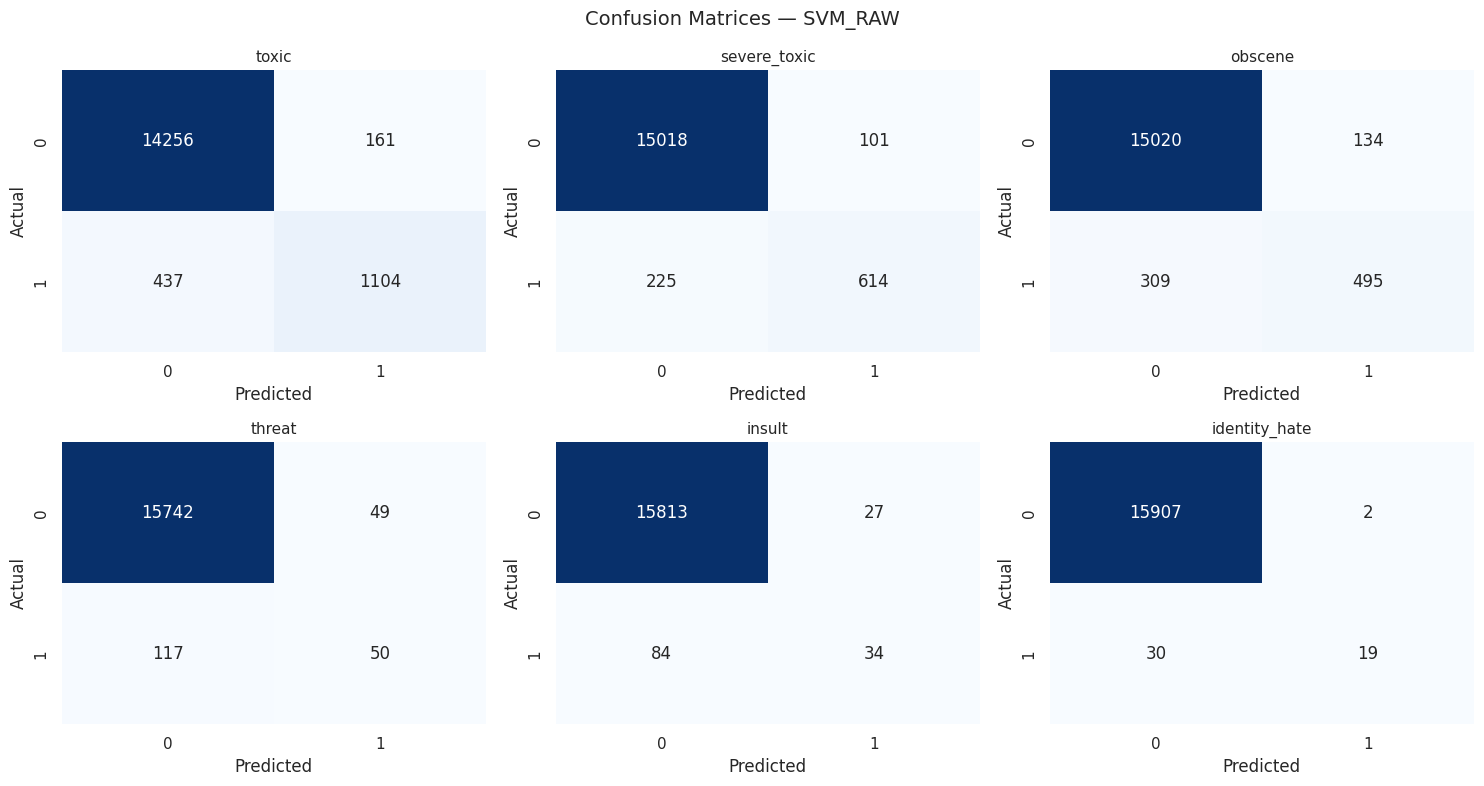

In [83]:
plot_confusion('SVM_RAW',y_test.values,y_pred_svm_raw,label_cols)

In [84]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [basic_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_raw.transform(sample_clean)
sample_pred = svm_raw.predict(sample_tfidf)

for text, pred in zip(sample_comments, sample_pred):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Amazing work
Prediction: Non-toxic


**Advanced clean version**

In [85]:
svm_clean= OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_clean.fit(X_train_tfidf_clean, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_svm_clean = svm_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 4.2s


In [86]:
evaluate('TF-IDF + SVM (advanced)', y_test.values, y_pred_svm_clean, train_t, infer_t)


===== TF-IDF + SVM (advanced) =====
  accuracy : 0.9187
  precision: 0.7193
  recall   : 0.4957
  f1 Macro : 0.5780
  train time: 4.2s


{'accuracy': 0.9187,
 'precision': 0.7193,
 'recall': 0.4957,
 'f1 (macro)': 0.578,
 'train time (s)': 4.2,
 'infer time (s)': 0.0}

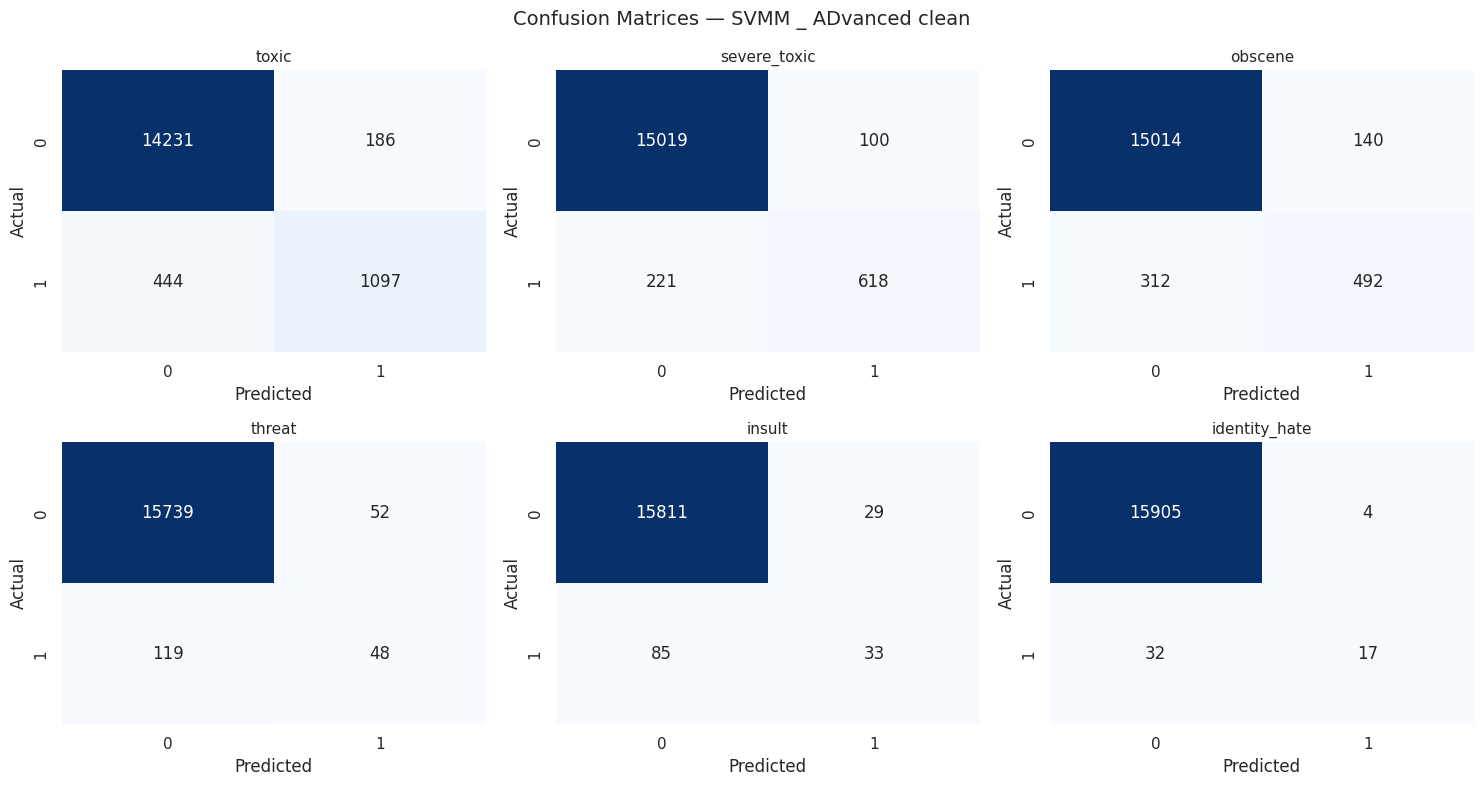

In [87]:
plot_confusion("SVMM _ ADvanced clean", y_test.values, y_pred_svm_clean, label_cols)

In [88]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

# preprocess
sample_clean = [advanced_preprocess(t) for t in sample_comments]

# tfidf transform
sample_tfidf = tfidf_raw.transform(sample_clean)

# prediction
sample_pred = svm_raw.predict(sample_tfidf)

for text, pred in zip(sample_comments, sample_pred):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Amazing work
Prediction: Non-toxic


# Model 3 — Bidirectional LSTM

In [89]:
from tensorflow.keras.layers import (Input, Embedding, LSTM, Dense,
                                      Dropout, Bidirectional, GlobalMaxPooling1D)


Building the model



In [102]:
EMBED_DIM = 128
NUM_LABELS = len(label_cols)

def build_bilstm(Vocab_size, max_len, num_labels):
    inp  = Input(shape=(max_len,))
    x    = Embedding(Vocab_size, EMBED_DIM)(inp)
    x    = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2))(x)
    x    = GlobalMaxPooling1D()(x)
    x    = Dense(128, activation='relu')(x)
    x    = Dropout(0.3)(x)
    out  = Dense(num_labels, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [103]:
lstm_model = build_bilstm(Vocab_size , max_len, NUM_LABELS)
lstm_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,396,102 (5.33 MB)

 Trainable params: 1,396,102 (5.33 MB)

 Non-trainable params: 0 (0.00 B)

Training the modle

In [104]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Model




In [105]:
callbacks =[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)
            ]
t0=time.time()
history = lstm_model.fit(
    X_train_lstm, y_train.values,
    validation_data=(X_test_lstm, y_test.values),
    epochs=10,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)
train_t = time.time() - t0

print(f'Train time: {train_t:.1f}s')

Epoch 1/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.8961 - loss: 0.0774 - val_accuracy: 0.9949 - val_loss: 0.0503 - learning_rate: 0.0010
Epoch 2/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9595 - loss: 0.0484 - val_accuracy: 0.9949 - val_loss: 0.0496 - learning_rate: 0.0010
Epoch 3/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9372 - loss: 0.0444 - val_accuracy: 0.9949 - val_loss: 0.0505 - learning_rate: 0.0010
Epoch 4/10
997/998 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9128 - loss: 0.0415
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.8907 - loss: 0.0404 - val_accuracy: 0.9949 - val_loss: 0.0521 - learning_rate: 0.0010
Epoch 5/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.8500 - loss: 0.0353 - val_accuracy: 0.9222 - val_loss: 0.0559 - learning_rate: 5.0000e-04
Train time: 87.8s


Plot training curves

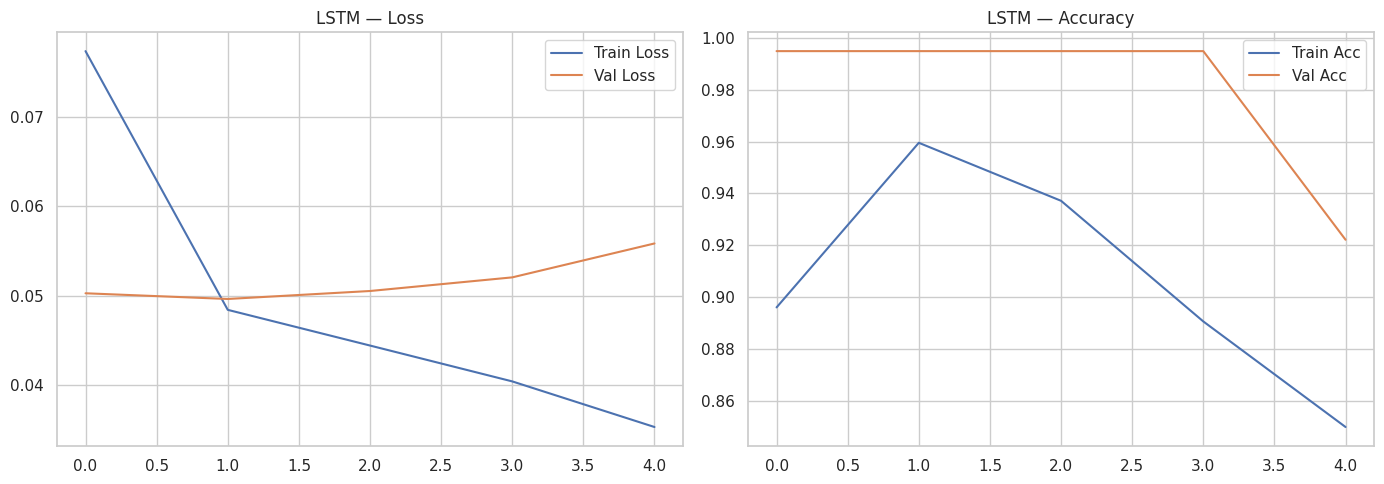

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM — Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('LSTM — Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [107]:
# Evaluate LSTM — Basic Clean (primary)
t0 = time.time()
y_pred_lstm = (lstm_model.predict(X_test_lstm) > 0.5).astype(int)
lstm_infer_t = time.time() - t0

evaluate('LSTM — Basic Clean', y_test.values, y_pred_lstm,
         train_t, lstm_infer_t)

499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

===== LSTM — Basic Clean =====
  accuracy : 0.9183
  precision: 0.4800
  recall   : 0.4389
  f1 Macro : 0.4538
  train time: 87.8s


{'accuracy': 0.9183,
 'precision': 0.48,
 'recall': 0.4389,
 'f1 (macro)': 0.4538,
 'train time (s)': 87.8,
 'infer time (s)': 2.9}

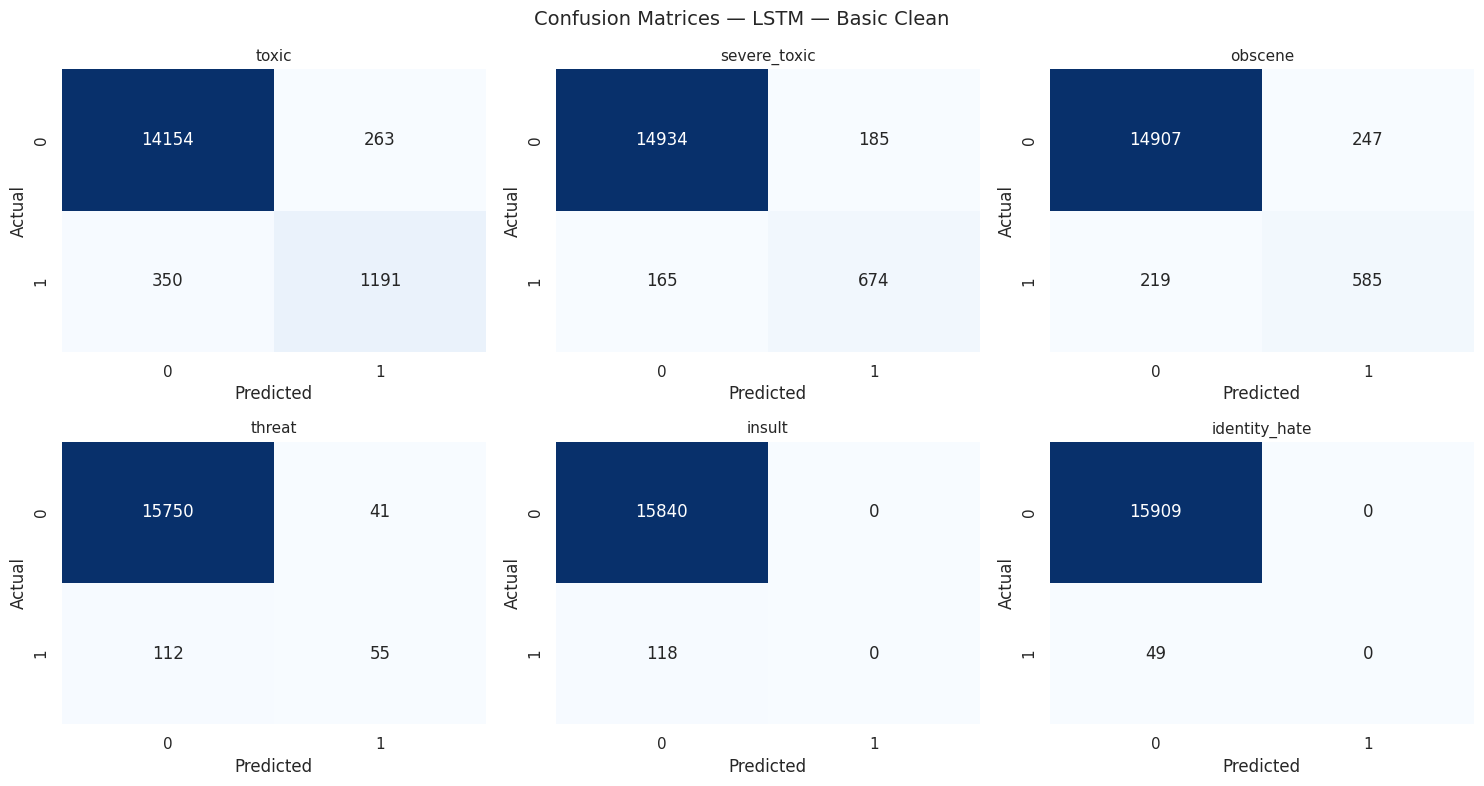

In [108]:
plot_confusion('LSTM — Basic Clean', y_test.values, y_pred_lstm,label_cols)

BiLSTM with raw data


In [109]:
lstm_tok_raw = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok_raw.fit_on_texts(X_train['raw'])

def to_padded_raw(texts):
    seqs = lstm_tok_raw.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen= max_len ,padding='post', truncating='post')

X_train_lstm_raw = to_padded_raw(X_train['raw'])
X_val_lstm_raw   = to_padded_raw(X_val['raw'])
X_test_lstm_raw  = to_padded_raw(X_test['raw'])

lstm_raw_model = build_bilstm(Vocab_size, max_len, NUM_LABELS)

t0 = time.time()
lstm_raw_model.fit(
    X_train_lstm_raw, y_train.values,
    validation_data=(X_val_lstm_raw, y_val.values),
    epochs=10, batch_size=256,
    callbacks=callbacks, verbose=1
)
lstm_raw_train_time = time.time() - t0

t0 = time.time()
y_pred_lstm_raw = (lstm_raw_model.predict(X_test_lstm_raw) > 0.5).astype(int)
lstm_raw_infer = time.time() - t0

Epoch 1/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.7951 - loss: 0.0984 - val_accuracy: 0.9927 - val_loss: 0.0513 - learning_rate: 0.0010
Epoch 2/10
497/499 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9537 - loss: 0.0509
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
499/499 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9540 - loss: 0.0495 - val_accuracy: 0.9927 - val_loss: 0.0498 - learning_rate: 0.0010
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.9500 - loss: 0.0451 - val_accuracy: 0.9927 - val_loss: 0.0505 - learning_rate: 5.0000e-04
499/499 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step


In [98]:
evaluate('LSTM — Raw', y_test.values, y_pred_lstm_raw, lstm_raw_train_time, lstm_raw_infer)


===== LSTM — Raw =====
  accuracy : 0.9176
  precision: 0.4824
  recall   : 0.4112
  f1 Macro : 0.4286
  train time: 47.8s


{'accuracy': 0.9176,
 'precision': 0.4824,
 'recall': 0.4112,
 'f1 (macro)': 0.4286,
 'train time (s)': 47.8,
 'infer time (s)': 2.8}

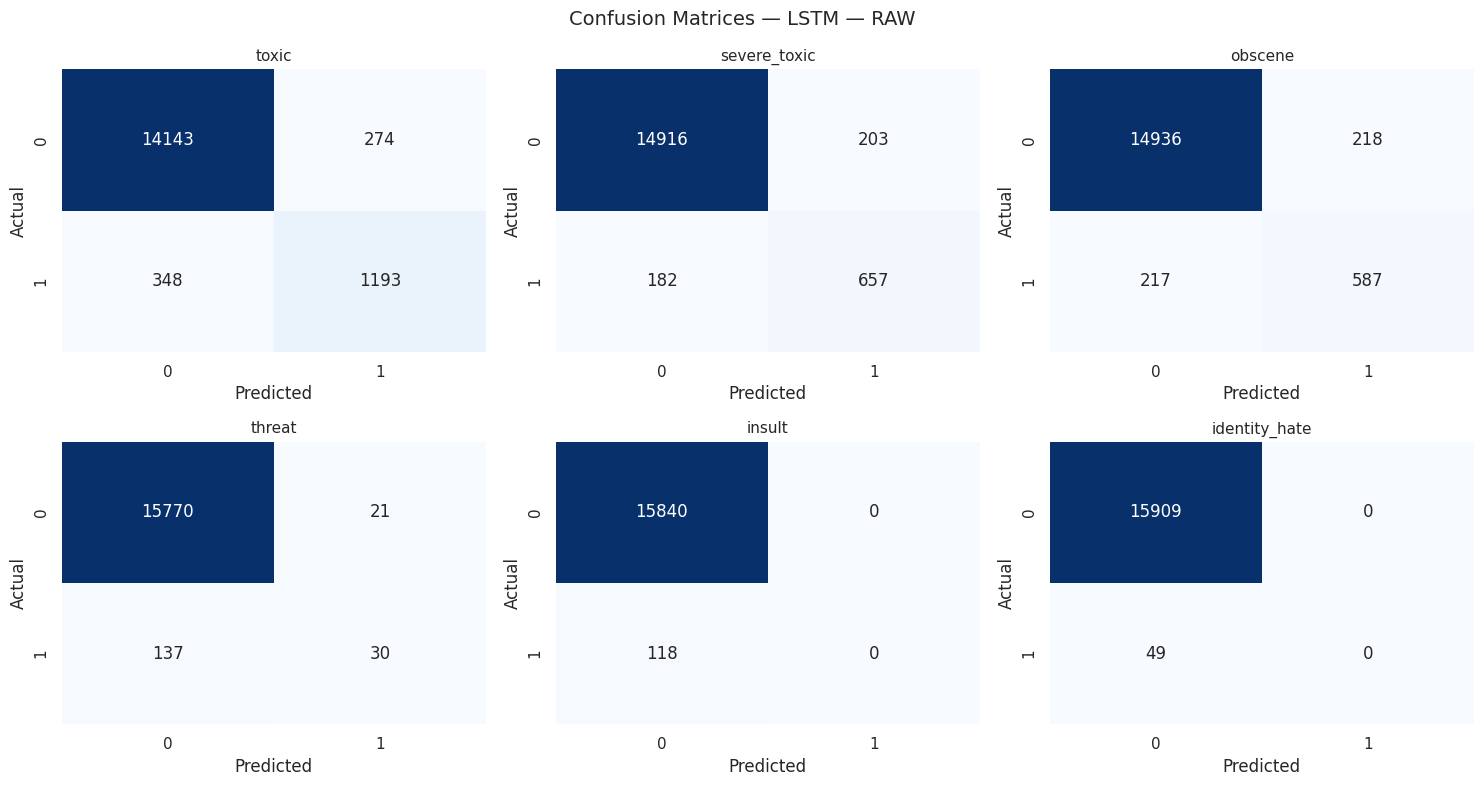

In [99]:
plot_confusion('LSTM — RAW', y_test.values, y_pred_lstm_raw,label_cols)

# Model 4 — BERT (Fine-tuned)

In [111]:
import torch
from torch.optim import AdamW
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.utils.data import Dataset, DataLoader

In [139]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Dataset
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = list(texts)
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.float)
        }

Device: cuda


if want to faster then bert_bath increase

or bert epochs 1

In [174]:
# Hyperparameters
BERT_BATCH = 32
BERT_EPOCHS = 1
BERT_MAX_LEN = 48

# Create datasets
train_ds = ToxicDataset(X_train['raw'].tolist(), y_train.values, Bert_tokenizer, BERT_MAX_LEN)
val_ds   = ToxicDataset(X_val['raw'].tolist(), y_val.values, Bert_tokenizer, BERT_MAX_LEN)
test_ds  = ToxicDataset(X_test['raw'].tolist(), y_test.values, Bert_tokenizer, BERT_MAX_LEN)


In [175]:
# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BERT_BATCH, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BERT_BATCH)
test_loader  = DataLoader(test_ds, batch_size=BERT_BATCH)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 3990
Val batches: 499


load model

In [176]:
from transformers import AutoModelForSequenceClassification

In [177]:
bert_model = BertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=NUM_LABELS,
    problem_type='multi_label_classification'
).to(DEVICE)


You are using a model of type distilbert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


Loading weights: 0it [00:00, ?it/s]

BertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.bias            | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.weight          | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.weight   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.sa_layer_norm.weight     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.weight   | UNEXPECTED | 
vocab_layer_norm.bias                 

Optimizer & scheduler

In [178]:
optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

total_steps = len(train_loader) * BERT_EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

criterion = torch.nn.BCEWithLogitsLoss()

print("BERT model ready.")

BERT model ready.


Training function

In [179]:
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()

    total_loss = 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(train):

        for batch in loader:

            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(outputs.logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), 1.0
                )

                optimizer.step()
                scheduler.step()

            total_loss += loss.item()

            preds = (
                torch.sigmoid(outputs.logits) > 0.5
            ).cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        np.vstack(all_preds),
        np.vstack(all_labels)
    )

Training Loop

Expected 20 min

# need to add
bert_train_losses = []
bert_val_losses = []
# before for epoch in range(BERT_EPOCHS):

In [180]:
best_val_loss = float('inf')

for epoch in range(BERT_EPOCHS):

    start = time.time()

    train_loss, _, _ = run_epoch(
        bert_model,
        train_loader,
        train=True
    )

    val_loss, val_preds, val_labels = run_epoch(
        bert_model,
        val_loader,
        train=False
    )

    val_f1 = f1_score(
        val_labels,
        val_preds,
        average='macro',
        zero_division=0
    )

    elapsed = time.time() - start

    print(
        f'Epoch {epoch+1}/{BERT_EPOCHS} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Val Loss: {val_loss:.4f} | '
        f'Val F1: {val_f1:.4f} | '
        f'Time: {elapsed:.0f}s'
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            bert_model.state_dict(),
            'best_bert.pt'
        )

print("Training complete.")

Epoch 1/1 | Train Loss: 0.0782 | Val Loss: 0.0556 | Val F1: 0.4245 | Time: 1216s
Training complete.


loss curve

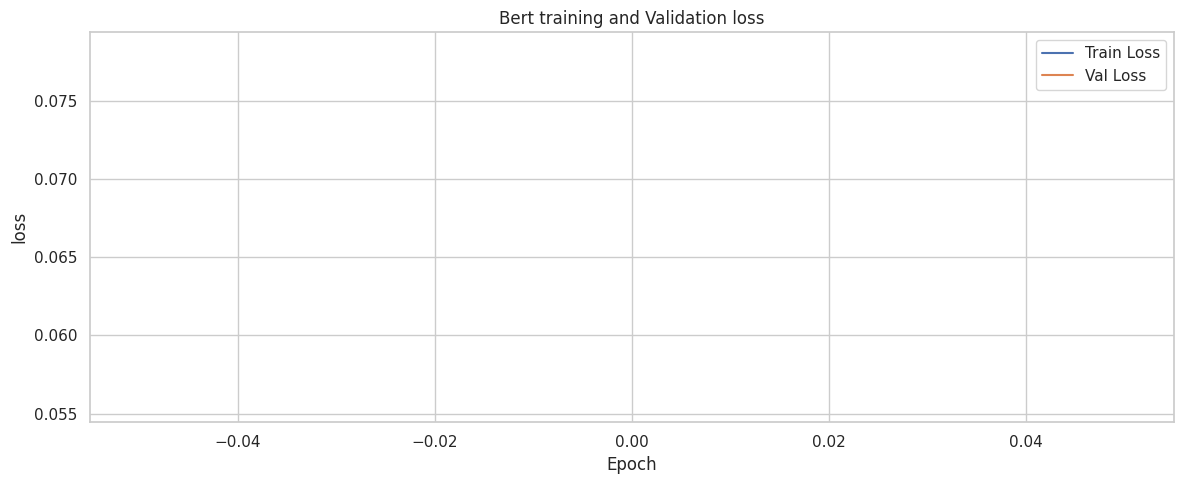

In [187]:
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Bert training and Validation loss')
plt.xlabel('Epoch'); plt.ylabel('loss'); plt.legend()
plt.tight_layout()
plt.savefig('bert_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()